# Research Question 2: What are the time series characteristics of UK moth counts? How to predict them or infill periods of missing data?

## Importing Libraries and Mounting Drive

In [1]:
# mounting drive
from google.colab import drive
drive.mount('/content/drive')

# importing libraries
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
import statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


Mounted at /content/drive


## Loading the Data

In [2]:
# importing libs
import pandas as pd

# actually loading the data
path = "/content/drive/MyDrive/Colab Notebooks/SCC 450 - Group Project/Week 10/Data/train_species.csv"
df = pd.read_csv(path, encoding="latin1")
df.head()

,SITECODE,LCODE,SAMPLE_DATE,FIELDNAME,VALUE,FROMDATE,SPERIOD_D,YEAR,WEEK_NEW,98_PERCENTILE,...,DRYTMP,NETRAD,SOLAR,STMP10,STMP30,SURWET,WDIR,WSPEED,RAIN,SPECIES_BIN
0,T07,1,2014-05-21,192,8,2014-05-14,7,2014,20,11.0,...,13.359167,117.612500,225.900000,9.224583,8.360417,60.000000,186.770833,6.473333,2.2,192
1,T07,1,1998-08-05,395,2,1998-08-04,1,1998,31,9.0,...,12.195833,110.416667,138.666667,13.325000,12.466667,14.666667,245.500000,7.183333,0.0,395
2,T10,3,2013-09-03,376,12,2013-09-02,1,2013,35,12.0,...,15.689583,90.491667,223.512500,16.483750,16.038333,0.206325,286.883333,3.338750,0.0,376
3,T09,1,2001-07-27,891,2,2001-07-26,1,2001,29,5.0,...,18.929167,158.375000,288.916667,18.654167,17.433333,0.708333,200.333333,0.629167,0.0,891
4,T01,1,1999-08-09,938,1,1999-08-08,1,1999,32,4.0,...,16.225000,17.916667,41.708333,18.291667,18.979167,34.125000,103.833333,2.633333,11.8,938


## Prophet Time Series Modelling

### Aggregation
- Want to aggregate on a typical weekly basis.
- Will also need to aggregate the other variables

In [3]:
# converting date
df['SAMPLE_DATE'] = pd.to_datetime(df['SAMPLE_DATE'])

# made a week column
df['STANDARD_WEEK'] = df['SAMPLE_DATE'].dt.to_period('W-SUN').dt.start_time

# normalise VALUE to avoid overcounting when aggregating
df['VALUE_NORM'] = df['VALUE'] / df['SPERIOD_D']

# defining aggs
aggs = {
    # using avg for met data
    'DRYTMP': 'mean',
    'NETRAD': 'mean',
    'SOLAR': 'mean',
    'STMP10': 'mean',
    'STMP30': 'mean',
    'SURWET': 'mean',
    'WDIR': 'mean',
    'WSPEED': 'mean',

    # but sum for rain
    'RAIN': 'sum',

    'VALUE_NORM': 'sum',
    'YEAR': 'max',
    #'STANDARD_WEEK': 'max'

}

# actually aggregating
df_spec_weekly = df.groupby(['SITECODE', 'STANDARD_WEEK', 'SPECIES_BIN']).agg(aggs).reset_index()

# lets just call it species count
df_spec_weekly = df_spec_weekly.rename(columns={'VALUE_NORM': 'SPECIES_COUNT'})

# results
print("\n-- Final weekly aggregated version")
print(df_spec_weekly.head())
print(f"Total Records: {len(df_spec_weekly):,}")


-- Final weekly aggregated version
  SITECODE STANDARD_WEEK SPECIES_BIN    DRYTMP    NETRAD      SOLAR    STMP10  \
0      T01    1992-12-28          XX -2.345833  4.583333  10.500000  0.429167   
1      T01    1993-01-04         590  7.312500  1.416667  11.875000  5.891667   
2      T01    1993-01-04         828  8.383333  6.166667  16.291667  5.033333   
3      T01    1993-01-04          XX  3.752083  8.083333  27.916667  2.647917   
4      T01    1993-01-11          XX  8.555833 -2.658333  25.866667  5.870000   

     STMP30     SURWET        WDIR    WSPEED  RAIN  SPECIES_COUNT  YEAR  
0  2.958333   5.875000    0.000000  0.000000   0.0            0.0  1993  
1  4.575000   2.625000  185.666667  1.229167   6.2            1.0  1993  
2  3.433333  32.083333  225.958333  1.620833   2.8            1.0  1993  
3  3.808333  17.416667  158.093750  1.655208   3.4            0.0  1993  
4  5.343333  12.475000  224.158333  3.405833  17.0            0.0  1993  
Total Records: 76,972


### Decomposition
- analyzing trend and seasonality of most significant species
- using the species with highest count at the target(most active site) site to find patterns
- seeing if prophet is feasible

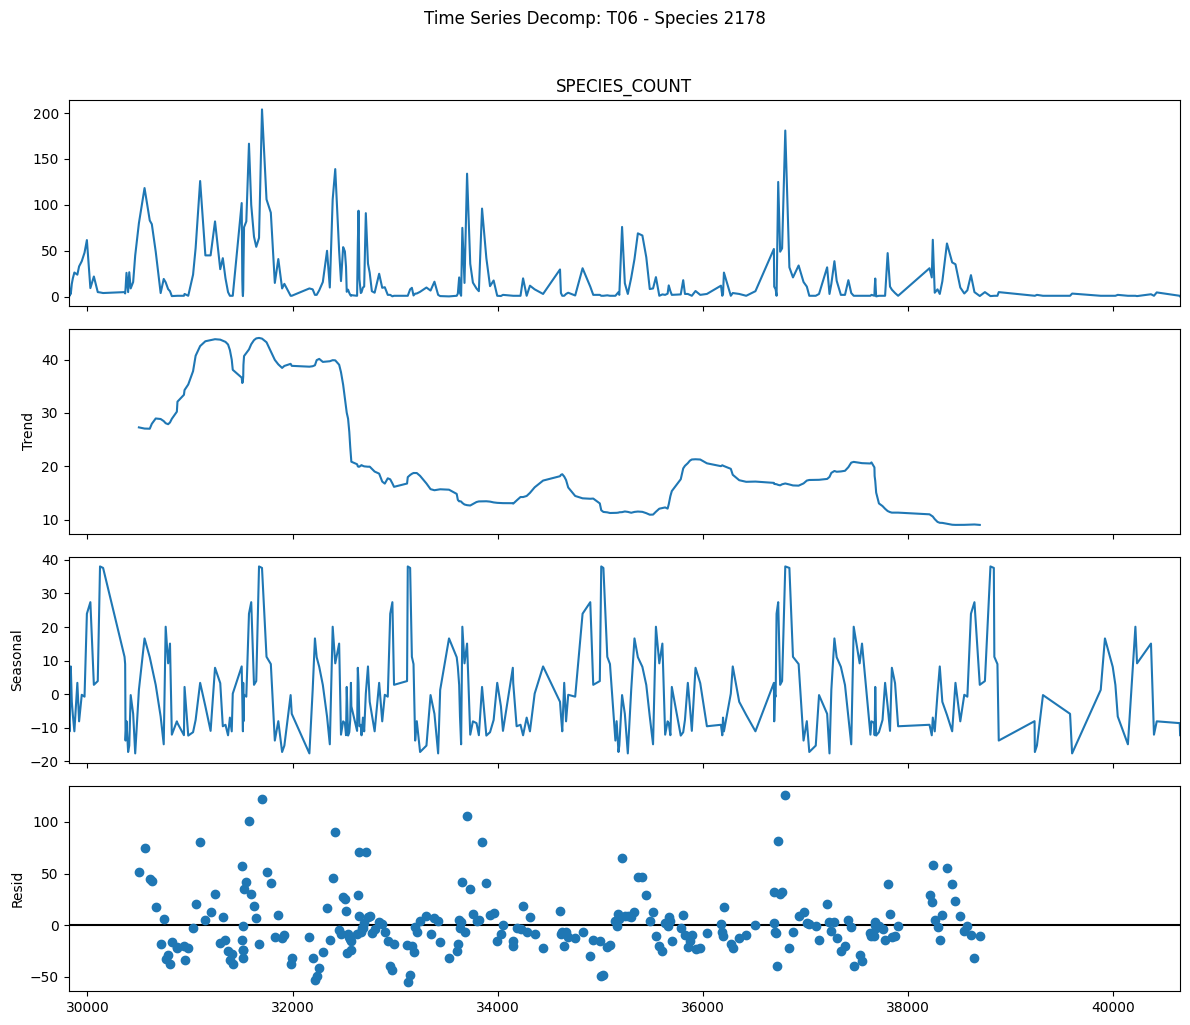

In [4]:
# finding most active site
active_records = df_spec_weekly[df_spec_weekly['SPECIES_COUNT'] > 0].copy()
site_activity = active_records.groupby('SITECODE')['SPECIES_COUNT'].sum().sort_values(ascending=False)
targetsite = site_activity.index[0]

# finding top spec at that sight
site_acc = active_records[active_records['SITECODE'] == targetsite]
spec_at_site = site_acc.groupby('SPECIES_BIN')['SPECIES_COUNT'].sum().sort_values(ascending=False)
topspec = spec_at_site.index[0]

# target series (will need this for SLT)
target_df = df_spec_weekly[(df_spec_weekly['SITECODE'] == targetsite) & (df_spec_weekly['SPECIES_BIN'] == topspec)].sort_values('STANDARD_WEEK')

# importing libs
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# actually decomposing
decomp_df = df_spec_weekly[(df_spec_weekly['SITECODE'] == targetsite) & (df_spec_weekly['SPECIES_BIN'] == topspec)].copy()
series = decomp_df['SPECIES_COUNT']

try:
  # using 52 aka weekly annual seasonality
  decomp = seasonal_decompose(series, model='additive', period=52)
  fig = decomp.plot()
  fig.suptitle(f'Time Series Decomp: {targetsite} - Species {topspec}', y=1.02)
  fig.set_size_inches(12, 10)
  plt.tight_layout()
  plt.show()
except Exception as e:
  print(f"\nCould not perform decomp")

## Installing Prophet

In [5]:
# installing prophet
!pip install prophet

In [6]:
import pandas as pd
from prophet import Prophet

# setting a single species at single site
df_target = df_spec_weekly[(df_spec_weekly['SITECODE'] == targetsite) & (df_spec_weekly['SPECIES_BIN'] == topspec)].copy()

# Prophet format is columns as ds and y
df_prophet = df_target.rename(columns={
    "STANDARD_WEEK": "ds",
    "SPECIES_COUNT": "y"
})

# sorting by ds(standard week)
df_prophet = df_prophet.sort_values("ds")

# weather data
met_data = ["DRYTMP", "NETRAD", "SOLAR", "STMP10", "STMP30", "SURWET", "WDIR", "WSPEED", "RAIN"]

# further split of test and train data
train = df_prophet.iloc[:-52]
test = df_prophet.iloc[-52:]


# creating an instance of the prophet model and filling in paramteres
m = Prophet(weekly_seasonality=False, yearly_seasonality=True, daily_seasonality=False, interval_width=0.9)

# adding regressors
for var in met_data:
  m.add_regressor(var)

# fitting
m.fit(train)

# creating dataframe for forecasting
future = m.make_future_dataframe(periods=52, freq='W')

# merging met predictors into it
future = future.merge(df_prophet[["ds"] + met_data], on="ds", how="left")

# making sure future regressor NaNs are filled
for var in met_data:
  future[var] = future[var].fillna(df_prophet[var].mean())

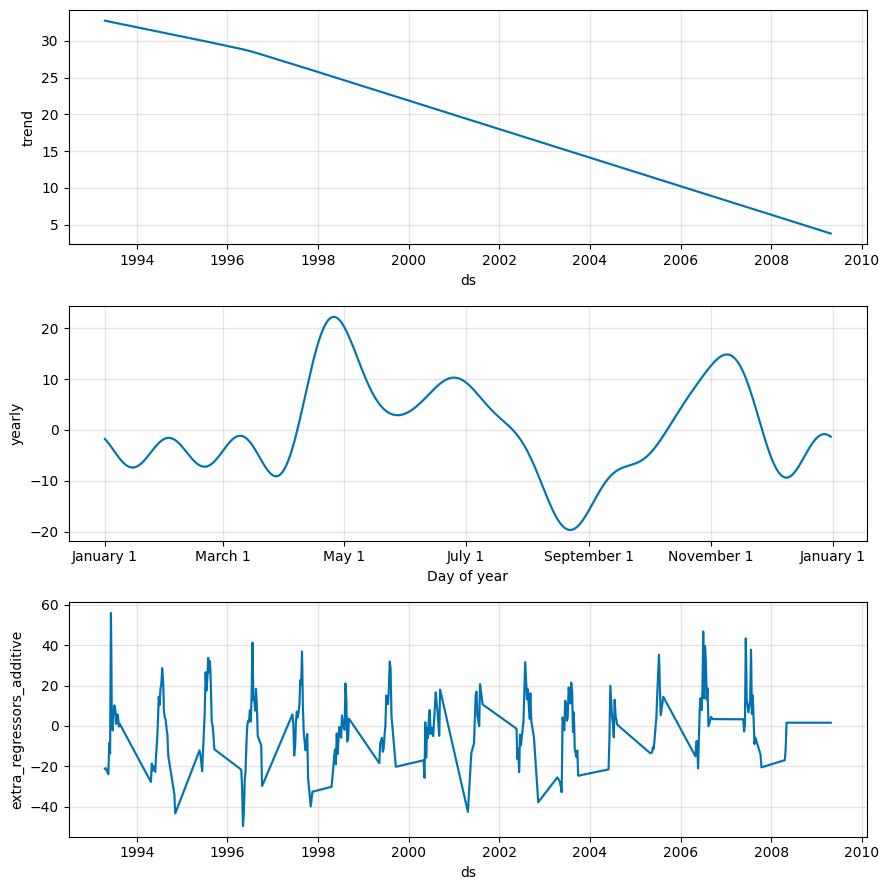

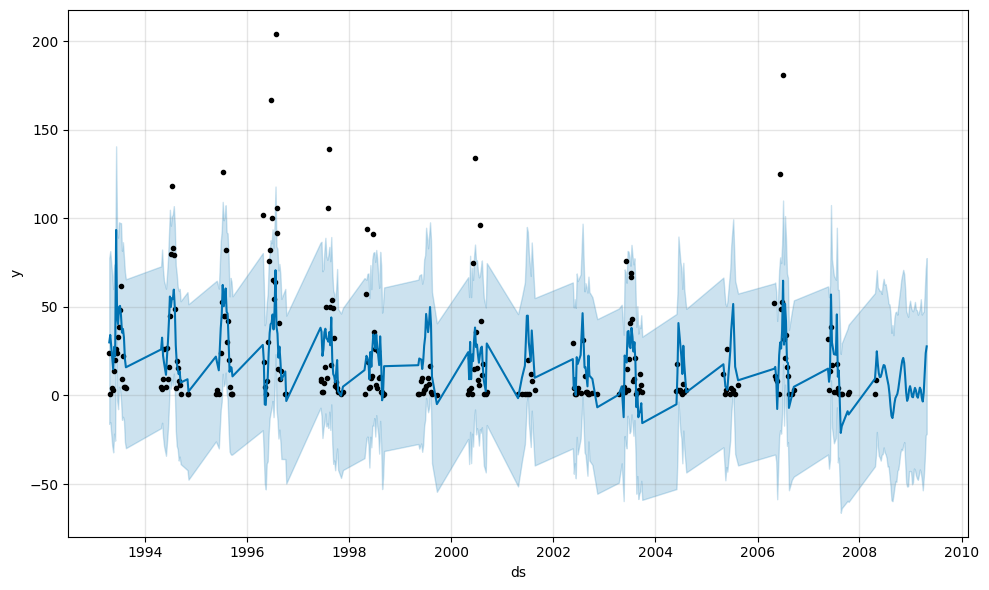

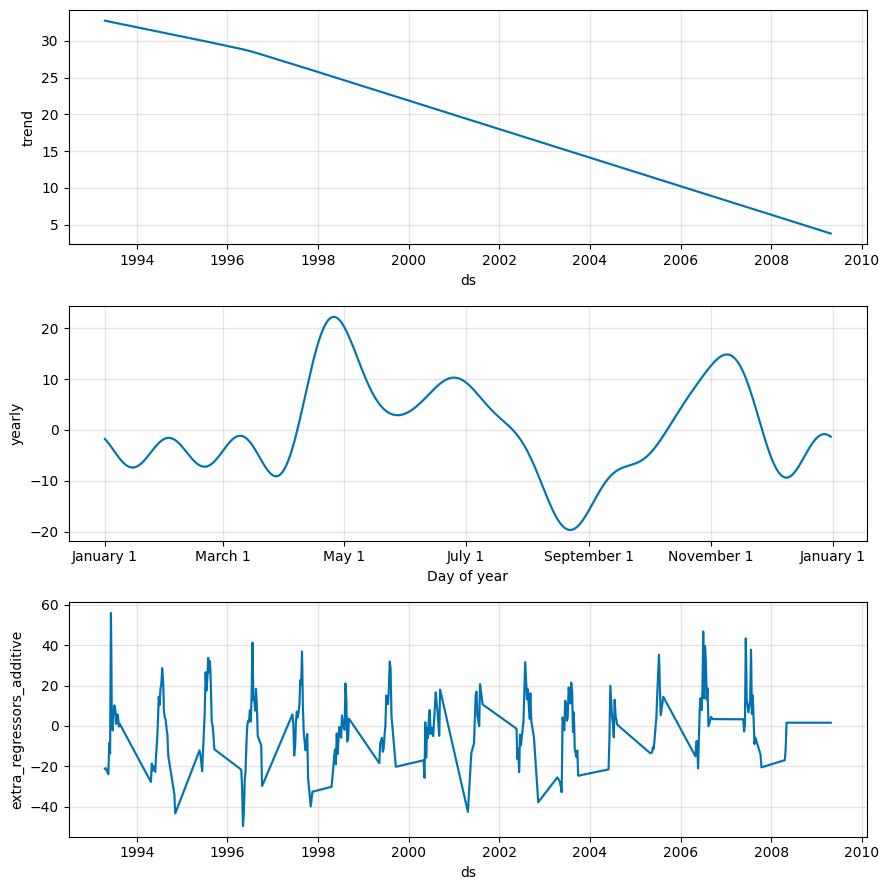

In [7]:
# actually generating forecast
forecast = m.predict(future)
m.plot(forecast)
m.plot_components(forecast)


# STL Decomposition
- validating the prophet findings

In [8]:
from statsmodels.tsa.seasonal import STL


In [9]:
# debugging
print("Standard week dtype:", target_df["STANDARD_WEEK"].dtype)
print("\nUnique STANDARD_WEEKs:")
print(target_df['STANDARD_WEEK'].head(10))
print("\nany NaT: ", target_df['STANDARD_WEEK'].isna().sum())
print("\nMin n Max week:", target_df['STANDARD_WEEK'].min(), target_df['STANDARD_WEEK'].max())

print("\nChecking if asfreq('W') breaks:")

Standard week dtype: datetime64[ns]

Unique STANDARD_WEEKs:
29816   1993-04-19
29827   1993-04-26
29833   1993-05-10
29838   1993-05-17
29848   1993-05-24
29858   1993-05-31
29873   1993-06-07
29902   1993-06-14
29919   1993-06-21
29945   1993-06-28
Name: STANDARD_WEEK, dtype: datetime64[ns]

any NaT:  0

Min n Max week: 1993-04-19 00:00:00 2015-06-08 00:00:00

Checking if asfreq('W') breaks:


In [10]:
# initializing ts for STL decomposition
ts = (target_df.set_index('STANDARD_WEEK')['SPECIES_COUNT'].sort_index())

# fixed issue w STANDARD_WEEK
weekly = pd.date_range(start=ts.index.min(), end=ts.index.max(), freq="W-MON")
ts = ts.reindex(weekly)

# filling in missing values
ts = ts.interpolate().ffill().bfill()

print("Length: ", len(ts))
print("Na count: ", ts.isna().sum())

Length:  1156
Na count:  0


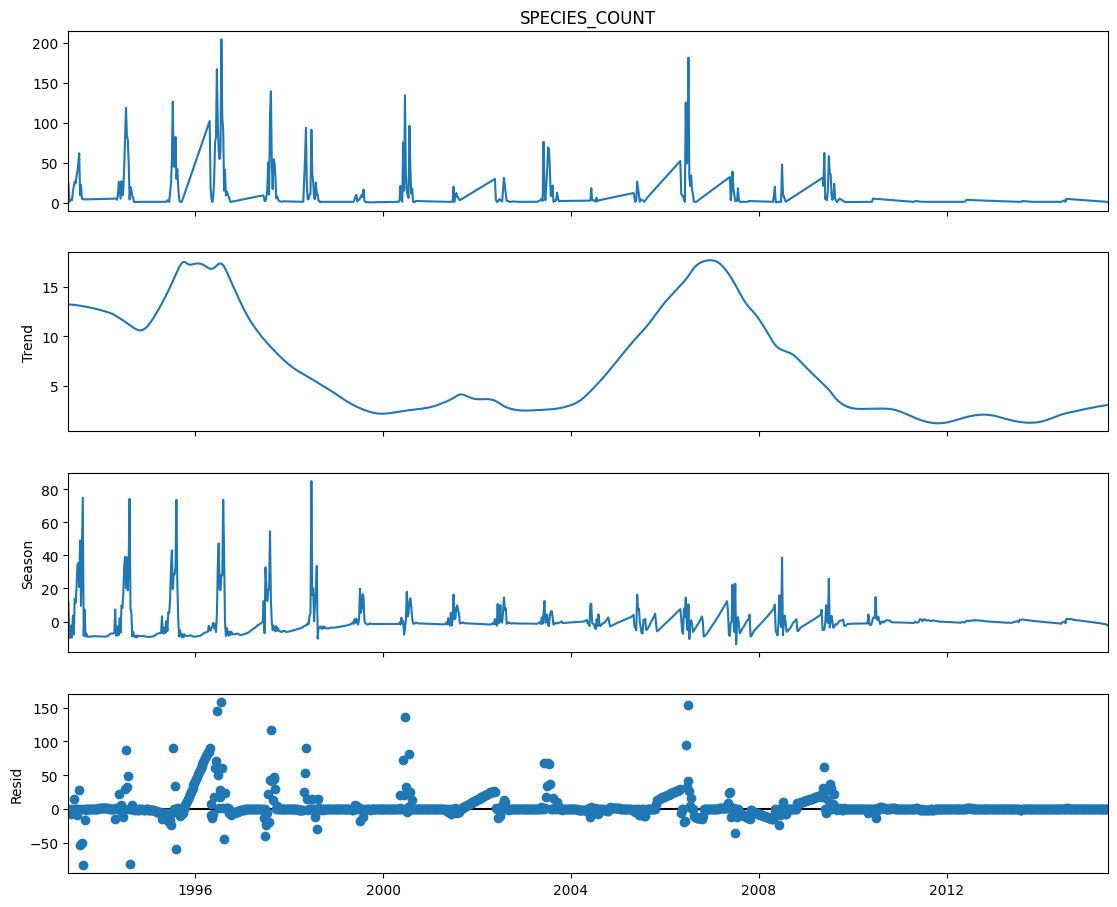

In [11]:
# actually running STL
stl = STL(ts, period=52, robust=True)
res = stl.fit()

# plotting
fig = res.plot()
fig.set_size_inches(12, 10)
plt.show()

## ACF/PACF
- ACF to compare how much does a week compare to same week last year, PACF for direct lag after removing the influence of intermediate lags


In [12]:
import statsmodels

<Figure size 1200x600 with 0 Axes>

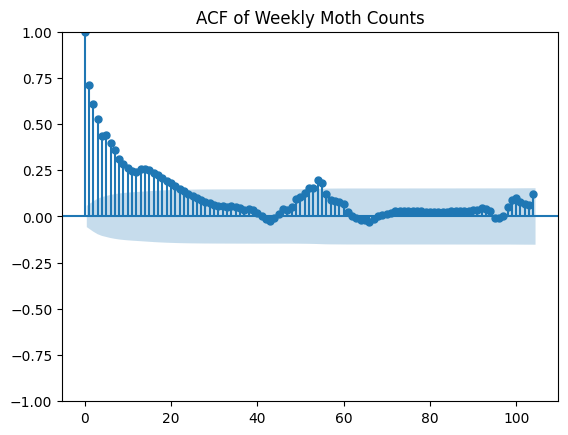

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# plotting acf
plt.figure(figsize=(12, 6))
plot_acf(ts, lags=104)
plt.title("ACF of Weekly Moth Counts")
plt.show()

<Figure size 1200x600 with 0 Axes>

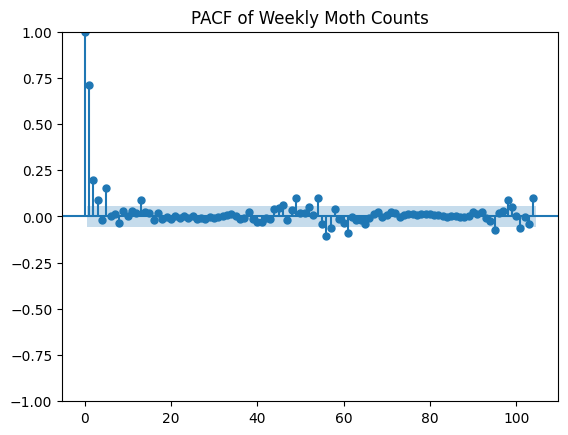

In [14]:
# plotting pacf
plt.figure(figsize=(12,6))
plot_pacf(ts, lags=104, method="ywm")
plt.title("PACF of Weekly Moth Counts")
plt.show()